In [1]:
import sys
import matplotlib.pyplot as plt
sys.path.append("../src")

In [2]:
from binomial import price_one_step_call

In [ ]:
S0 = 100
K = 110
Su, Sd, Cu, Cd, delta, B, price = price_one_step_call( S0, K, 1.10, 0.8, 4)

<class 'float'> 110.00000000000001
<class 'float'> 80.0
<class 'float'> 1.4210854715202004e-14
<class 'int'> 0
<class 'float'> 3.979039320256559e-14


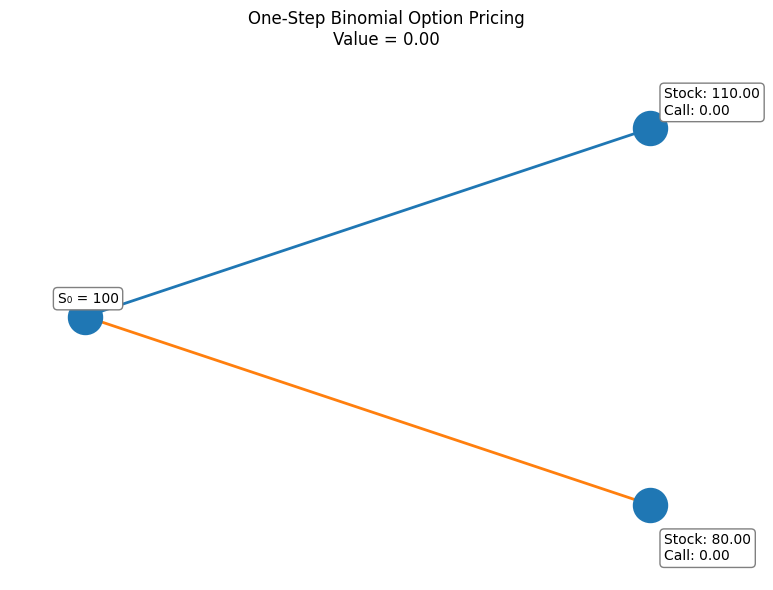

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 6))

# Node positions
root = (0, 0)
up = (1.5, 1)
down = (1.5, -1)

# Branches
ax.plot([root[0], up[0]], [root[1], up[1]], lw=2)
ax.plot([root[0], down[0]], [root[1], down[1]], lw=2)

# Nodes
ax.scatter(
    [root[0], up[0], down[0]],
    [root[1], up[1], down[1]],
    s=600,
    zorder=3
)

# Labels done using AI
bbox = dict(boxstyle="round,pad=0.3", fc="white", ec="gray")

ax.annotate(
    "S₀ = 100",
    root,
    xytext=(-20, 10),
    textcoords="offset points",
    bbox=bbox
)

ax.annotate(
    f"Stock: {Su:.2f}\nCall: {Cu:.2f}",
    up,
    xytext=(10, 10),
    textcoords="offset points",
    bbox=bbox
)

ax.annotate(
    f"Stock: {Sd:.2f}\nCall: {Cd:.2f}",
    down,
    xytext=(10, -40),
    textcoords="offset points",
    bbox=bbox
)

ax.set_title(
    f"One-Step Binomial Option Pricing\nValue = {price:.2f}",
)

ax.set_xlim(-0.2, 1.8)
ax.set_ylim(-1.4, 1.4)
ax.axis("off")

plt.tight_layout()
plt.show()


### Trying MultiStep tree from basics

In [73]:
class Stock_tree:
    def __init__(self, up, down, rate_of_interest, probability): 
        self.up = up
        self.down = down
        self.rate = rate_of_interest
        self.p = probability
        
    def make_tree(self,  level, max_level, index, stock_price):
        if level > max_level :
            return None
        MyNode = Node(stock_price)
        MyNode.left = self.make_tree(level + 1, max_level, 2**index, stock_price * self.down)
        MyNode.right = self.make_tree(level + 1, max_level, 2**index + 1, stock_price * self.up)

        return MyNode
    
    def make_tree_list(self, level, max_level, stock_price):
        if level == max_level:
            return stock_price

        return [
            stock_price,
            self.make_tree_list(level + 1, max_level, stock_price * self.down),
            self.make_tree_list(level + 1, max_level, stock_price * self.up)]

    def reduced_tree(self, max_level, stock_price):
        stock_tree = [ ]
        for step in range(max_level + 1):
            level = []

            for up_moves in range(step + 1):

                S = round(stock_price * (self.up ** up_moves) * (self.down ** (step - up_moves)), 2)

                level.append(S)

            stock_tree.append(level)
        return stock_tree
    
    def option_pricing(self, stock_tree, strike_price):
        option_payoff = []
        for i in stock_tree[-1]:
            option_payoff.append(max(i - strike_price, 0))
        return option_payoff
    
    def backward_induction(self, payoffs):

        values = payoffs

        while len(values) > 1:

            new_values = []

            for i in range(len(values)-1):

                Vd = values[i]
                Vu = values[i+1]

                V = (
                self.p * Vu +
                (1-self.p) * Vd
                )/(1+self.rate)

                new_values.append(round(V,2))

            print(new_values)

            values = new_values
        return values[0]
    

In [74]:
tree = Stock_tree(1.1, 0.9, 0.05, 0.5)

result = tree.reduced_tree(5, 100)
a = tree.option_pricing(result, 105)
s = tree.backward_induction(a)
s

[0.0, 0.0, 1.34, 14.09, 39.44]
[0.0, 0.64, 7.35, 25.49]
[0.3, 3.8, 15.64]
[1.95, 9.26]
[5.34]


5.34

This seems much harder also... also.. I wanna check something


In [30]:
node.right.left.value is node.left.right.value

False

Wouldn't it be better if they were the same object if they represent the same state... :)

Lets try storing it using List

